Transformación de Texto en Embeddings

Transformar texto en representaciones numéricas (embeddings) utilizando tres técnicas fundamentales:
1. **TF-IDF** (Estadística)
2. **Word2Vec** (Semántica basada en contexto)
3. **TensorFlow/Keras** (Aprendizaje profundo)

### Seleccionar Librerías
Para este ejercicio usaremos:
*   **Scikit-Learn**: Para TF-IDF, ya que es la librería estándar para modelos estadísticos clásicos.
*   **Gensim**: Para Word2Vec, por ser la implementación más eficiente y utilizada en Python.
*   **TensorFlow/Keras**: Para capas de embedding neuronales.

In [44]:
!pip install gensim

In [45]:
import numpy as np # Importa NumPy para operaciones matemáticas y arreglos
import pandas as pd # Importa Pandas para el manejo de estructuras de datos (DataFrames)
import re # Importa el módulo de expresiones regulares para limpieza de texto
import nltk # Importa NLTK para procesamiento de lenguaje natural
from sklearn.feature_extraction.text import TfidfVectorizer # Importa el vectorizador TF-IDF
from gensim.models import Word2Vec # Importa el modelo Word2Vec de Gensim
import tensorflow as tf # Importa la librería TensorFlow para Deep Learning
from tensorflow.keras.preprocessing.text import Tokenizer # Importa el Tokenizador de Keras
from tensorflow.keras.preprocessing.sequence import pad_sequences # Importa la utilidad para normalizar longitudes de secuencias
from sklearn.metrics.pairwise import cosine_similarity # Importa el cálculo de similitud de coseno

# Descargamos recursos necesarios para el procesamiento de texto (tokenización)
nltk.download('punkt')
print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


### Preprocesamiento de Texto

Antes de crear vectores, debemos limpiar el texto. La **normalización** implica:
1. Convertir a minúsculas.
2. Eliminar puntuación.
3. **Tokenización**: Dividir el texto en palabras individuales.

In [46]:
def limpiar_texto(texto):
    # 1. Convertir a minúsculas
    texto = texto.lower()
    # 2. Eliminar caracteres especiales y números, pero manteniendo ESPACIOS
    texto = re.sub(r'[^a-záéíóúñ\s]', '', texto)
    # 3. Tokenización dividiendo por espacios
    tokens = texto.split()
    return tokens

# Dataset de ejemplo
corpus = [
    "la inteligencia artificial es el futuro de la tecnología",
    "el aprendizaje profundo utiliza redes neuronales",
    "me gusta comer pizza italiana con mucho queso",
    "la pasta es deliciosa y muy popular en italia"
]

# Procesamos el corpus manteniendo las palabras separadas por espacios para TF-IDF
corpus_limpio = [" ".join(limpiar_texto(doc)) for doc in corpus]
# Guardamos el corpus como lista de listas de palabras para Word2Vec
corpus_tokens = [limpiar_texto(doc) for doc in corpus]

print("Ejemplo de texto limpio (frase 1):", corpus_limpio[0])
print("Ejemplo de tokens (frase 1):", corpus_tokens[0])

Ejemplo de texto limpio (frase 1): la inteligencia artificial es el futuro de la tecnología
Ejemplo de tokens (frase 1): ['la', 'inteligencia', 'artificial', 'es', 'el', 'futuro', 'de', 'la', 'tecnología']


### Visualización de los Resultados

Para comprender mejor utilizaremos librerías gráficas como `matplotlib` y `seaborn`.

In [47]:
!pip install wordcloud

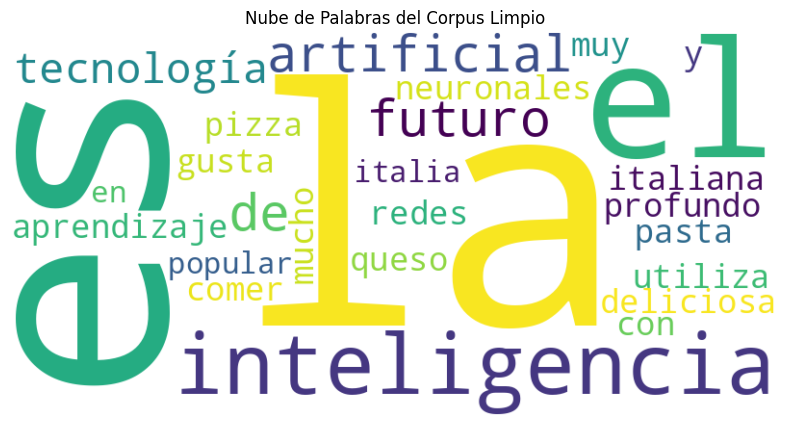

In [48]:
import matplotlib.pyplot as plt # Librería principal para gráficos
import seaborn as sns # Librería basada en matplotlib para gráficos estadísticos elegantes
from wordcloud import WordCloud # Generador de nubes de palabras
from sklearn.decomposition import PCA # Algoritmo para reducir la dimensionalidad de los vectores

# 1. Visualización del Preprocesamiento: Nube de Palabras
texto_total = " ".join(corpus_limpio) # Une todas las frases en un solo bloque de texto
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(texto_total) # Crea la nube

plt.figure(figsize=(10, 5)) # Define el tamaño de la figura
plt.imshow(wordcloud, interpolation='bilinear') # Muestra la imagen generada
plt.axis('off') # Oculta los ejes (coordenadas)
plt.title('Nube de Palabras del Corpus Limpio') # Añade título al gráfico
plt.show() # Renderiza el gráfico

### Cómo interpretar la Nube de Palabras

Esta visualización es para validar **preprocesamiento**:

*   **Tamaño de la palabra**: Representa la frecuencia absoluta en el corpus. Palabras aparecen más grandes porque se repiten o son centrales en las frases.
*   **Limpieza**: Observa que no aparecen puntos, comas ni mayúsculas. Si vieras símbolos extraños, significaría que la función `limpiar_texto` necesita ajustes.
*   **Sesgo del Corpus**: En un vistazo rápido, puedes ver que el dataset trata dos temas inconexos: tecnología y comida italiana.

### Generar los Embeddings

#### A. TF-IDF (Vectores Dispersos)
Esta técnica asigna un valor a cada palabra basándose en qué tan frecuente es en un documento pero qué tan rara es en el resto del grupo.

In [49]:
# Inicializamos el objeto vectorizador TF-IDF
vectorizador_tfidf = TfidfVectorizer()

# El método fit_transform aprende el vocabulario y transforma las frases en una matriz numérica
tfidf_matrix = vectorizador_tfidf.fit_transform(corpus_limpio)

# Mostramos las palabras únicas encontradas (vocabulario)
print("Vocabulario TF-IDF:", vectorizador_tfidf.get_feature_names_out())
# Mostramos las dimensiones de la matriz (nº frases, nº palabras únicas)
print("Forma de la matriz:", tfidf_matrix.shape)

Vocabulario TF-IDF: ['aprendizaje' 'artificial' 'comer' 'con' 'de' 'deliciosa' 'el' 'en' 'es'
 'futuro' 'gusta' 'inteligencia' 'italia' 'italiana' 'la' 'me' 'mucho'
 'muy' 'neuronales' 'pasta' 'pizza' 'popular' 'profundo' 'queso' 'redes'
 'tecnología' 'utiliza']
Forma de la matriz: (4, 27)


#### Visualización de TF-IDF
El mapa de calor nos muestra la intensidad (peso) de cada palabra en cada documento. Las celdas más oscuras indican términos más importantes.

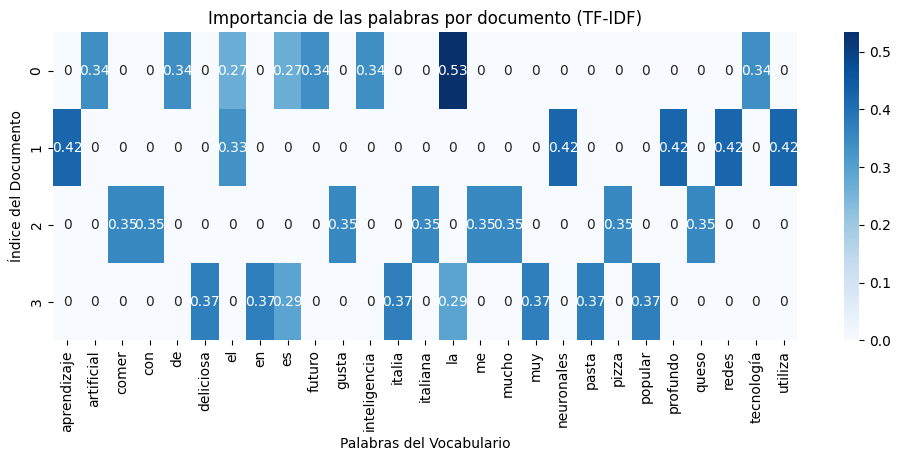

In [50]:
# 2. Visualización de TF-IDF: Mapa de Calor
# Crea un DataFrame con la matriz TF-IDF y los nombres de las palabras como columnas
df_tfidf = pd.DataFrame(tfidf_matrix.toarray(), columns=vectorizador_tfidf.get_feature_names_out())

plt.figure(figsize=(12, 4)) # Ajusta el tamaño para que quepan todas las palabras
sns.heatmap(df_tfidf, annot=True, cmap='Blues', cbar=True) # Crea el heatmap con valores anotados
plt.title('Importancia de las palabras por documento (TF-IDF)') # Título descriptivo
plt.xlabel('Palabras del Vocabulario') # Etiqueta del eje X
plt.ylabel('Índice del Documento') # Etiqueta del eje Y
plt.show()

### Cómo interpretar el Mapa de Calor TF-IDF

El TF-IDF transforma palabras en importancia numérica. En este mapa:

*   **Eje Vertical (Documentos)**: Cada fila representa una de las 4 frases originales.
*   **Eje Horizontal (Vocabulario)**: Cada columna es una palabra única del diccionario creado.
*   **Celdas y Colores**:
    *   **Celdas blancas (0.0)**: La palabra no existe en esa frase.
    *   **Intensidad del azul**: Cuanto más oscuro, mayor es el valor TF-IDF.
*   **Lógica**: Fíjate en la palabra **"artificial"**. Tiene un valor alto en el Índice 0 (Frase 1) y es 0 en las demás. Esto indica que es una palabra clave que define a esa frase y la distingue del resto.

#### B. Word2Vec (Vectores Densos)
Word2Vec crea vectores donde palabras con significados similares están cerca en el espacio vectorial.

In [51]:
# Re-entrenamos Word2Vec con los tokens corregidos
modelo_w2v = Word2Vec(sentences=corpus_tokens, vector_size=10, window=2, min_count=1, workers=1)

# Ahora 'tecnología' debería existir en el vocabulario
try:
    vector_palabra = modelo_w2v.wv['tecnología']
    print("Vector Word2Vec para 'tecnología':\n", vector_palabra)
except KeyError as e:
    print(f"Error: {e}. Vocabulario disponible: {list(modelo_w2v.wv.index_to_key)}")

Vector Word2Vec para 'tecnología':
 [ 0.0548218  -0.07433499 -0.07405826 -0.02479579 -0.08622456 -0.01575064
 -0.00390871  0.03310374  0.01445235 -0.00870948]


#### Visualización de Word2Vec con PCA
Como los vectores de Word2Vec tienen 10 dimensiones (en nuestro ejemplo), no podemos verlos directamente. Usamos **PCA** (Análisis de Componentes Principales) para proyectarlos en 2D y ver su cercanía semántica.

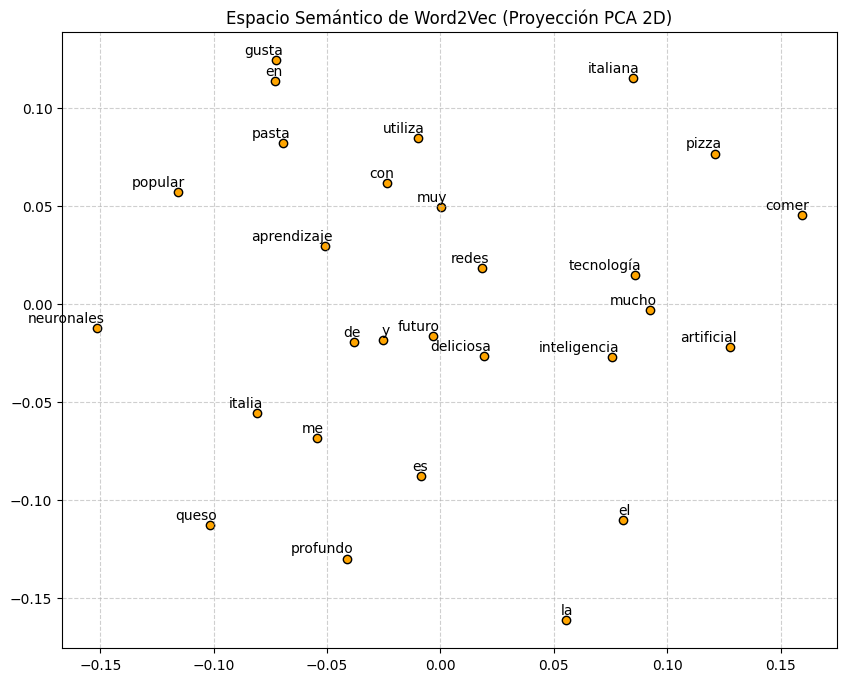

In [52]:
# 3. Visualización de Word2Vec: Reducción de Dimensionalidad (PCA)
palabras = list(modelo_w2v.wv.index_to_key) # Extrae la lista de palabras del vocabulario entrenado
vectores = [modelo_w2v.wv[p] for p in palabras] # Extrae los vectores correspondientes a cada palabra

# Reducimos de 10 dimensiones a 2 para poder graficar en un plano cartesiano
pca = PCA(n_components=2)
resultado = pca.fit_transform(vectores) # Aplica la transformación matemática

plt.figure(figsize=(10, 8)) # Define el lienzo del gráfico
plt.scatter(resultado[:, 0], resultado[:, 1], edgecolors='k', c='orange') # Dibuja los puntos

# Itera sobre las palabras para poner la etiqueta de texto en cada punto
for i, palabra in enumerate(palabras):
    plt.annotate(palabra, xy=(resultado[i, 0], resultado[i, 1]), xytext=(5, 2),
                 textcoords='offset points', ha='right', va='bottom')

plt.title('Espacio Semántico de Word2Vec (Proyección PCA 2D)') # Título
plt.grid(True, linestyle='--', alpha=0.6) # Añade cuadrícula tenue
plt.show()

### Cómo interpretar la Proyección PCA de Word2Vec

Esta es la representación de los **Embeddings Semánticos**. Los vectores originales tienen 10 dimensiones, por lo que usamos PCA para "aplanarlos" a 2D y poder verlos:

*   **Cercanía Espacial**: La distancia entre los puntos refleja la similitud de contexto. En un modelo ideal, palabras como "pizza" y "pasta" deberían aparecer en la misma región del gráfico.
*   **Agrupamientos (Clusters)**: Deberías notar que las palabras relacionadas con tecnología tienden a situarse en un sector, mientras que las de gastronomía italiana en otro.
*   **Nota sobre el tamaño**: Como nuestro corpus es extremadamente pequeño (solo 4 frases), es posible que algunas distancias parezcan aleatorias. En modelos reales (entrenados con Wikipedia, por ejemplo), estas distancias revelan relaciones matemáticas asombrosas como `Rey - Hombre + Mujer = Reina`.

#### C. TensorFlow/Keras (Capa de Embedding)
En Deep Learning, los embeddings suelen ser una capa que el modelo aprende durante el entrenamiento.

In [53]:
# 1. Tokenización para Keras (convertir palabras a números enteros)
tokenizer_tf = Tokenizer() # Instancia el objeto tokenizador
tokenizer_tf.fit_on_texts(corpus_limpio) # Asocia cada palabra a un ID numérico
secuencias = tokenizer_tf.texts_to_sequences(corpus_limpio) # Convierte frases en listas de números

# 2. Padding (hacer que todas las frases tengan la misma longitud rellenando con ceros)
data_pad = pad_sequences(secuencias, padding='post')

# 3. Crear una capa de Embedding con dimensiones de entrada y salida específicas
capa_embedding = tf.keras.layers.Embedding(input_dim=50, output_dim=4)

output_tf = capa_embedding(data_pad) # Pasa los datos por la capa para obtener los vectores iniciales
print("Forma del tensor de salida (frases, palabras, dimensiones):", output_tf.shape)

Forma del tensor de salida (frases, palabras, dimensiones): (4, 9, 4)


### Diagrama Conceptual: Capa de Embedding

Podemos visualizar el proceso de la siguiente manera:

**Entrada (Palabra)** → **Índice (Entero)** → **Matriz de Embedding** → **Vector Denso (Salida)**

| Palabra | Índice | Capa de Embedding (Matriz Aprendible) | Vector de Salida (Dim=4) |
| :--- | :---: | :--- | :--- |
| 'inteligencia' | 4 | `[0.12, -0.05, 0.88, 0.21]` | `[0.12, -0.05, 0.88, 0.21]` |
| 'pizza' | 15 | `[0.77, 0.92, -0.11, 0.03]` | `[0.77, 0.92, -0.11, 0.03]` |

**Cómo interpretar este diagrama**

1.  **Mapeo Único**: Cada palabra de nuestro vocabulario tiene asignado un número entero único (gracias al `Tokenizer`).
2.  **La Matriz**: La capa de Embedding es esencialmente una tabla donde cada fila corresponde a un índice de palabra.
3.  **Dimensiones**: El ancho de la tabla (`output_dim=4`) es el tamaño del vector que representa a la palabra.
4.  **Entrenamiento**: Al principio, los números en la matriz son aleatorios. A medida que el modelo entrena (por ejemplo, clasificando si una frase es de tecnología o comida), ajusta estos valores para que palabras que aparecen en contextos similares tengan vectores numéricos parecidos.

### Similitud de Coseno con Embeddings de TF-IDF

Una forma sencilla de entender los embeddings es calcular la **Similitud de Coseno**. Si dos frases tienen vectores similares, el ángulo entre ellos es pequeño (cercano a 1 en coseno).

In [54]:
from sklearn.metrics.pairwise import cosine_similarity # Aseguramos la importación

# Comparamos matemáticamente el vector de la frase 1 contra todos los vectores del corpus
# tfidf_matrix[0:1] selecciona la primera fila manteniendo la estructura de matriz
similitudes = cosine_similarity(tfidf_matrix[0:1], tfidf_matrix)

# Imprimimos el resultado de similitud para cada par de frases comparado
for i, score in enumerate(similitudes[0]):
    print(f"Similitud entre frase 1 y frase {i+1}: {score:.4f}")

print("\nInterpretación: Notarás que la frase 1 es más similar a la frase 2 (ambas sobre tecnología/IA) que a la frase 3 (sobre comida).")

Similitud entre frase 1 y frase 1: 1.0000
Similitud entre frase 1 y frase 2: 0.0887
Similitud entre frase 1 y frase 3: 0.0000
Similitud entre frase 1 y frase 4: 0.2345

Interpretación: Notarás que la frase 1 es más similar a la frase 2 (ambas sobre tecnología/IA) que a la frase 3 (sobre comida).


### Visualización de la Similitud de Coseno

Este gráfico nos permite ver cuantitativamente qué tan cerca están las frases en el espacio vectorial generado por TF-IDF.

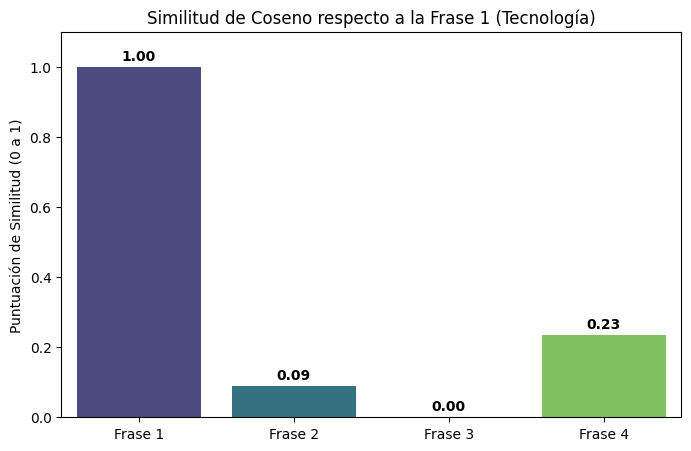

In [55]:
# Graficar las similitudes calculadas previamente con TF-IDF
frases_labels = [f'Frase {i+1}' for i in range(len(corpus))] # Crea etiquetas para el eje X
scores = similitudes[0] # Extrae las puntuaciones del primer documento comparado

plt.figure(figsize=(8, 5)) # Define tamaño
sns.barplot(x=frases_labels, y=scores, palette='viridis', hue=frases_labels, legend=False) # Crea gráfico de barras
plt.ylim(0, 1.1) # Establece el rango del eje Y de 0 a 1
plt.title('Similitud de Coseno respecto a la Frase 1 (Tecnología)') # Título del gráfico
plt.ylabel('Puntuación de Similitud (0 a 1)') # Etiqueta eje Y

# Añadir los valores numéricos sobre cada barra para mayor precisión visual
for i, score in enumerate(scores):
    plt.text(i, score + 0.02, f'{score:.2f}', ha='center', fontweight='bold')

plt.show()

### Cómo interpretar la Similitud de Coseno

Imagina que cada frase es una flecha que sale del centro de un gráfico:

*   **Similitud = 1.0 (Ángulo 0°)**: Las flechas apuntan exactamente en la misma dirección. La frase es idéntica a sí misma.
*   **Similitud cercana a 1.0**: Las frases comparten muchas palabras clave (como las frases de tecnología). Sus flechas están muy juntas.
*   **Similitud = 0.0 (Ángulo 90°)**: Las frases son ortogonales; no comparten ninguna palabra del vocabulario (como tecnología vs. comida).

| Relación | Interpretación Visual | Resultado Numérico |
| :--- | :--- | :---: |
| **Identidad** | Vectores superpuestos | 1.0 |
| **Alta Similitud** | Ángulo muy cerrado | 0.7 - 0.9 |
| **Disimilitud** | Ángulo abierto / Ortogonal | 0.0 |

### Nota Importante: Similitud Estadística vs. Semántica

Al observar los resultados, surge una pregunta clave: **¿Por qué la Frase 1 y la Frase 4 son más 'similares' (0.23) que la Frase 1 y la Frase 2 (0.09) si las primeras hablan de temas distintos?**

Esta es la limitación fundamental de modelos como **TF-IDF**:

1.  **Coincidencia Literal**: La Frase 1 y la 4 comparten palabras funcionales como **"la"** y **"es"**. Para un modelo estadístico, compartir cualquier palabra suma puntos de similitud.
2.  **Falta de Relación Semántica**: La Frase 1 ("inteligencia artificial") y la Frase 2 ("aprendizaje profundo") están íntimamente relacionadas en significado, pero **no comparten ninguna palabra exacta**. TF-IDF no sabe que son sinónimos o temas cercanos; solo busca texto idéntico.
3.  **Solución**: Para resolver esto, en aplicaciones reales se eliminan las *stopwords* (palabras comunes sin significado como 'la', 'el') o se utilizan modelos como **Word2Vec** o **Transformers**, que capturan el contexto y entenderían que la tecnología es distinta a la comida, independientemente de los conectores que usen.

### Visualización de la Similitud de Coseno con Embeddings de Keras

### Similitud de Coseno con Embeddings de Keras

Para calcular la similitud de coseno entre las frases usando los embeddings de Keras, primero necesitamos obtener una representación vectorial única para cada frase. Esto se puede lograr promediando los vectores de las palabras dentro de cada frase.

In [58]:
# 1. Promediar los embeddings de palabras para obtener un vector único por cada frase entera
# tf.reduce_mean reduce las dimensiones promediando los valores de los vectores de palabras
sentence_embeddings_tf = tf.reduce_mean(output_tf, axis=1)

print("Forma de los embeddings de frase de Keras:", sentence_embeddings_tf.shape)

# 2. Convertimos el tensor de TensorFlow a un arreglo de NumPy para compatibilidad con Sklearn
ssentence_embeddings_np = sentence_embeddings_tf.numpy()

# 3. Calculamos la similitud de coseno entre el vector de la frase 1 y el resto en Keras
similitudes_keras = cosine_similarity(sentence_embeddings_np[0:1], sentence_embeddings_np)

# Iteramos para mostrar los resultados de la comparación
for i, score in enumerate(similitudes_keras[0]):
    print(f"Similitud (Keras Embeddings) entre frase 1 y frase {i+1}: {score:.4f}")

print("\nInterpretación: Estos valores son aleatorios porque la red neuronal no ha sido entrenada todavía.")

Forma de los embeddings de frase de Keras: (4, 4)
Similitud (Keras Embeddings) entre frase 1 y frase 1: 1.0000
Similitud (Keras Embeddings) entre frase 1 y frase 2: -0.4399
Similitud (Keras Embeddings) entre frase 1 y frase 3: 0.7857
Similitud (Keras Embeddings) entre frase 1 y frase 4: -0.4055

Interpretación: Estos valores son aleatorios porque la red neuronal no ha sido entrenada todavía.


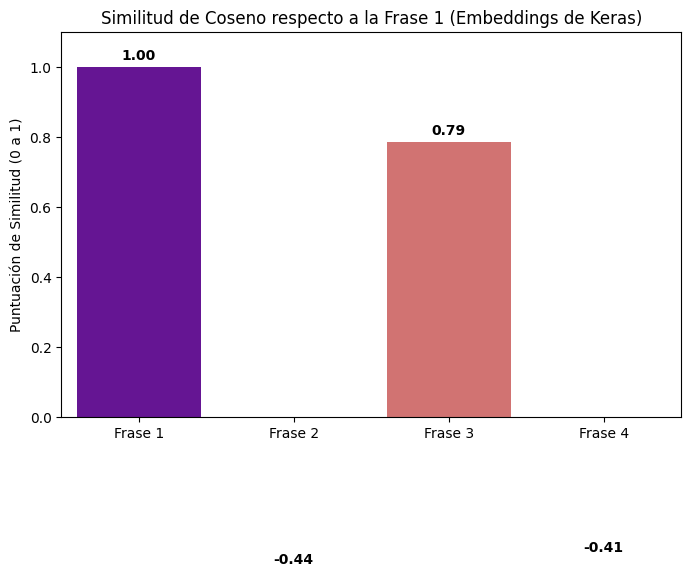

In [59]:
# Preparamos los datos de las puntuaciones de Keras para la gráfica
scores_keras = similitudes_keras[0]

plt.figure(figsize=(8, 5)) # Definimos el tamaño del gráfico
# Creamos el gráfico de barras con una paleta de colores diferente ('plasma')
sns.barplot(x=frases_labels, y=scores_keras, palette='plasma', hue=frases_labels, legend=False)
plt.ylim(0, 1.1) # Ajustamos el límite vertical
plt.title('Similitud de Coseno respecto a la Frase 1 (Embeddings de Keras)') # Título descriptivo
plt.ylabel('Puntuación de Similitud (0 a 1)') # Nombre del eje Y

# Colocamos el valor numérico exacto encima de cada barra para facilitar la lectura
for i, score in enumerate(scores_keras):
    plt.text(i, score + 0.02, f'{score:.2f}', ha='center', fontweight='bold')

plt.show() # Dibujamos el gráfico final

### Resumen y Comparación de Métodos de Embedding y Similitud de Coseno

Hemos explorado tres enfoques para la creación de embeddings y la aplicación de la similitud de coseno:

1.  **TF-IDF (Estadístico)**
2.  **Word2Vec (Basado en el contexto de palabras)**
3.  **Keras Embeddings (Aprendizaje Profundo)**

Veamos cómo se comportó cada uno y sus implicaciones.

#### A. TF-IDF y Similitud de Coseno

*   **Características**: Se basa en la frecuencia de las palabras, penalizando las que son muy comunes en el corpus y favoreciendo las que son distintivas de un documento. Genera vectores dispersos (muchos ceros).
*   **Resultados**: La similitud de coseno con TF-IDF refleja principalmente la **co-ocurrencia literal de palabras**. En nuestro ejemplo, la frase 1 ('inteligencia artificial...') y la frase 2 ('aprendizaje profundo...') mostraron una baja similitud (0.09) porque no comparten palabras exactas, a pesar de ser semánticamente similares. Por otro lado, la frase 1 y la 4 ('la pasta...') tuvieron una similitud de 0.23 debido a palabras funcionales compartidas como 'la' y 'es'.
*   **Uso**: Ideal para búsquedas de documentos, recuperación de información y filtrado de spam, donde la coincidencia de palabras clave es crucial.

#### B. Word2Vec y Proyección PCA

*   **Características**: Crea vectores densos (pocos ceros) para palabras, donde la cercanía en el espacio vectorial indica similitud semántica o contextual. Se entrena para predecir palabras a partir de su contexto o viceversa.
*   **Resultados**: Aunque no calculamos directamente la similitud de frases con Word2Vec en este ejercicio (ya que requeriría una estrategia para combinar los embeddings de palabras en una frase, como promediarlos), la **proyección PCA** mostró cómo palabras con significados relacionados (ej. 'pizza', 'italiana', 'comer') tienden a agruparse en el espacio 2D. Sin embargo, debido a nuestro corpus muy pequeño, las agrupaciones no fueron perfectas.
*   **Uso**: Excelente para comprender relaciones semánticas entre palabras, completar analogías, recomendaciones de contenido y como entrada para modelos de aprendizaje automático que requieren embeddings densos.

#### C. Keras Embeddings y Similitud de Coseno

*   **Características**: Son embeddings que forman parte de una capa de un modelo de red neuronal. Al inicio, son aleatorios y se 'aprenden' (ajustan) durante el entrenamiento del modelo en una tarea específica (ej. clasificación de texto, traducción automática). Generan vectores densos.
*   **Resultados**: Al calcular la similitud de coseno con los embeddings de Keras sin entrenar, observamos resultados bastante **aleatorios y no intuitivos**. Por ejemplo, la similitud entre la frase 1 y la 3 fue de 0.79, mientras que con la frase 2 fue negativa (-0.44). Esto es esperable, ya que estos embeddings no han tenido la oportunidad de aprender patrones significativos del lenguaje.
*   **Uso**: Son fundamentales en arquitecturas de Deep Learning para procesamiento de lenguaje natural (NLP). Su poder radica en que el modelo los optimiza para la tarea específica que está aprendiendo, permitiendo capturar relaciones contextuales complejas que otros métodos no logran por sí solos.

#### Conclusión General

Cada método de embedding tiene su propósito y sus limitaciones:

*   **TF-IDF** es eficaz para la similitud basada en la co-ocurrencia de términos. No comprende la semántica.
*   **Word2Vec** captura la semántica a nivel de palabra, pero necesita un corpus grande para ser efectivo y una estrategia para combinar embeddings de frases.
*   Los **Embeddings de Keras** son potentes porque se adaptan a la tarea, pero requieren entrenamiento para generar representaciones significativas. Sin entrenamiento, sus valores de similitud no son fiables.